In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
# Standard library imports
import os
import shutil

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
from affine import Affine
import contextily as ctx
from scipy import ndimage

# Geospatial imports
from osgeo import gdal
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import mapping
from shapely.geometry import Point
import rasterio
from rasterio.plot import show
from rasterio import features
from rasterio.features import rasterize
from pysheds.grid import Grid
from rasterio.mask import mask
import pyflwdir

# Local/custom module imports
import hoydedata_api
from NVE_FKB_Api import get_sql_db
from resampletif import resample_tif_by_resolution

### Definere verdier for grunnleggende funksjon av scripten.

In [ ]:
## DEFINE VARIABLES
# IN-SCRIPT-VALUES
vassdrag_nr = "015"         # Nummer av vassdraget fra fkb-databasen. Check number based on FKB data.
target_res = 5              # Ønsket oppløsning i meter for DTM og avledede produkter.
burn_depth= 2               # Elv innbrenningsdybde, originalt 50m men dette scriptet fungerer godt med 0m
buffer=0                    # buffer av piksler ved elv-midtlinje for innbrenning.
min_area = 1                # Minimum areal km^2 for sub-nedbørfelt kartlegging.
upa_min = 1.0               # Minimum oppeareal for flomplanskartet i km^2.
buffer_distance_m = 25      # Bufferavstand i meter for område rundt hovedelvene som omskrives små elv i flomkartet.
versjon = "v0.9.25"         # Versjonsnummer for output-filer, oppdater ved endringer i scriptet.  

In [50]:
## VARIABLES - DO NOT CHANGE
all_touched=True            # ENDRE IKKE - alle celler som berøres av elvelinjen vil bli brent.
close_iter=1                # ENDRE IKKE - Closing kan hjelpe til med å fylle små hull i elvelinjene.
dilate_iter=1               # ENDRE IKKE - Dilation kan hjelpe til med å sikre at elvelinjene blir fullt fanget.

In [51]:
# FKBvann data - Nedbørfelt
# For å laste ned alle vassdragene
# OPTIONS:
# For original version, use vann.Nedborfelt_NFeltF (This misses coastal areas)
# For an updated version, use vann.Nedborfelt_VassOmrF (This includes coastal areas but combines some smaller areas)
FKB_Nedborfelt = get_sql_db(bounds=None, dbname='innsyn', table='vann.Nedborfelt_VassOmrF',  server='gis-sql04')
FKB_Nedborfelt.head(2)


,OBJECTID,GDB_GEOMATTR_DATA,OBJTYPE,VASSOMR,NAVNVASSOMR,LANDAREAL,AREAL_KM2,GlobalID,geometry
0,1,None,Vassdragsområde,001,Haldenvassdraget/Iddefjorden,2495,2507,None,"POLYGON ((306943.572 6663967.992, 306933.564 6..."
1,2,None,Vassdragsområde,002,Glommavassdraget/Hvaler og Singlefjorden,42445,43115,None,"POLYGON ((338040.914 6977828.96, 338026.362 69..."


### Søk her for vassdraget ditt

In [52]:
# Define your search term
query_obj = "Numedal"  # Replace with your desired substring

# Search for rows where 'navnNedbf' contains the substring (case-insensitive) if using NFeltF
# If using VassOmrF, the column name for region is NAVNVASSOMR
results = FKB_Nedborfelt[FKB_Nedborfelt['NAVNVASSOMR'].str.contains(query_obj, case=False, na=False)]

results

,OBJECTID,GDB_GEOMATTR_DATA,OBJTYPE,VASSOMR,NAVNVASSOMR,LANDAREAL,AREAL_KM2,GlobalID,geometry
14,15,None,Vassdragsområde,015,Numedalslågen og Siljanvassdraget/kyst Sandefj...,6275,6514,None,"POLYGON ((97775.042 6732788.521, 97686.159 673..."


### Nedfra her er bare for utviklere, ikke brukere

In [53]:
## GETTING NBF BOUNDARY FROM FKB DATA
def get_nbf_bounds(fkb_nedborfelt: gpd.GeoDataFrame, vassdrag_nr: str) -> tuple:
    """
    Get the exact bounding box coordinates for a specific drainage basin (nedbørfelt)
    based on its vassdragNr and return the basin polygon.
    
    Args:
        fkb_nedborfelt: GeoDataFrame containing watershed data
        vassdrag_nr: The vassdragNr identifier for the desired drainage basin
        
    Returns:
        tuple: ((xmin, ymin, xmax, ymax), basin_gdf) - bounds and the basin GeoDataFrame
    """
    # Filter the dataset to get only the specified drainage basin
    basin = fkb_nedborfelt[fkb_nedborfelt['VASSOMR'] == vassdrag_nr] # vassdragNr when using NFeltF, VASSOMR when using VassOmrF
    
    if basin.empty:
        raise ValueError(f"No drainage basin found with VASSOMR: {vassdrag_nr}")
    
    # Get the basin name
    basin_name = basin.iloc[0]['NAVNVASSOMR'] if 'NAVNVASSOMR' in basin.columns else "Unknown"
    
    # Get the exact bounds of the filtered basin
    xmin, ymin, xmax, ymax = basin.total_bounds
    
    print(f"Bounds for VASSOMR {vassdrag_nr} ({basin_name}):")
    print(f"xmin: {xmin}, ymin: {ymin}, xmax: {xmax}, ymax: {ymax}")
    
    return (xmin, ymin, xmax, ymax), basin

Bounds for VASSOMR 015 (Numedalslågen og Siljanvassdraget/kyst Sandefjord-Mølen):
xmin: 72423.23000000045, ymin: 6540117.98, xmax: 231352.83660000004, ymax: 6733362.02


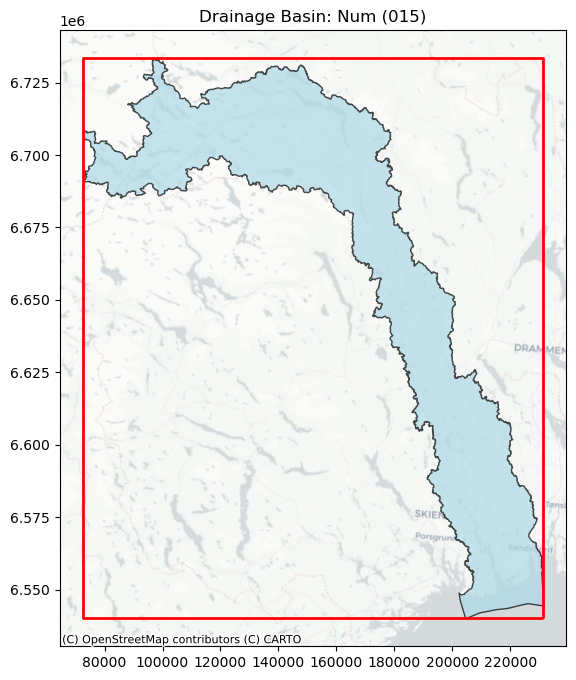

In [54]:
# Define vassdrag_nr for import. Can be found in FKB_Nedbørfelt dataset.
vassdrag_bounds, vassdrag_basin_gdf = get_nbf_bounds(FKB_Nedborfelt, vassdrag_nr)

# Create a bounding box for visualization
vassdrag_bbox = box(*vassdrag_bounds)
vassdrag_bbox_gdf = gpd.GeoDataFrame(geometry=[vassdrag_bbox], crs=FKB_Nedborfelt.crs)

# Visualization of the selected basin and its bounding box
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the specific basin polygon
vassdrag_basin_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7)

# Plot the bounding box
vassdrag_bbox_gdf.boundary.plot(ax=ax, color='red', linewidth=2)

# Get the basin name for the title
vassdrag_basin_name = vassdrag_basin_gdf.iloc[0]['NAVNVASSOMR'] if 'NAVNVASSOMR' in vassdrag_basin_gdf.columns else "Unknown"
vassdrag_basin_name = vassdrag_basin_name[:3]

# Add title and other elements
plt.title(f"Drainage Basin: {vassdrag_basin_name} ({vassdrag_nr})")

# Clip name to reduce issues:


# Optional: Add basemap for context
try:
    ctx.add_basemap(ax, crs=FKB_Nedborfelt.crs.to_string(),
                    source=ctx.providers.CartoDB.Positron)
except:
    pass  # Skip if contextily is not available or fails

#DisplayBounds
dxmin = vassdrag_bounds[0]-0.001e6
dymin = vassdrag_bounds[1]-0.001e6
dxmax = vassdrag_bounds[2]+0.001e6
dymax = vassdrag_bounds[3]+0.001e6
dbounds = dxmin, dymin, dxmax, dymax

In [55]:
# FKBvann data - ELVIS
# Grab lake/river data with rough clipping to boundary box of vassdrag
FKB_ELVIS = get_sql_db(bounds=vassdrag_bounds, dbname='innsyn', table='vann.ElvenettL',  server='gis-sql04')
FKB_INNSJO = get_sql_db(bounds=vassdrag_bounds, dbname='innsyn', table='vann.N50_InnsjoFlate', server='gis-sql04')

## Clip lake/river data by border of vassdrag
ELVIS_lim_vassdrag = gpd.clip(FKB_ELVIS, vassdrag_basin_gdf)
INNSJO_lim_vassdrag = gpd.clip(FKB_INNSJO, vassdrag_basin_gdf)

# Show unique objtype values
unique_elv = ELVIS_lim_vassdrag["objektType"].unique()
#print("Unique values in 'objektType' column:")
#print(unique_elv)
unique_innsjo = INNSJO_lim_vassdrag["objektType"].unique()
#print("Unique values in 'objektType' column:")
#print(unique_innsjo)

C:\Users\thob\AppData\Local\Temp\10\ipykernel_39100\3140778497.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right')
C:\Users\thob\AppData\Local\Temp\10\ipykernel_39100\3140778497.py:40: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax2.legend(loc='upper right')


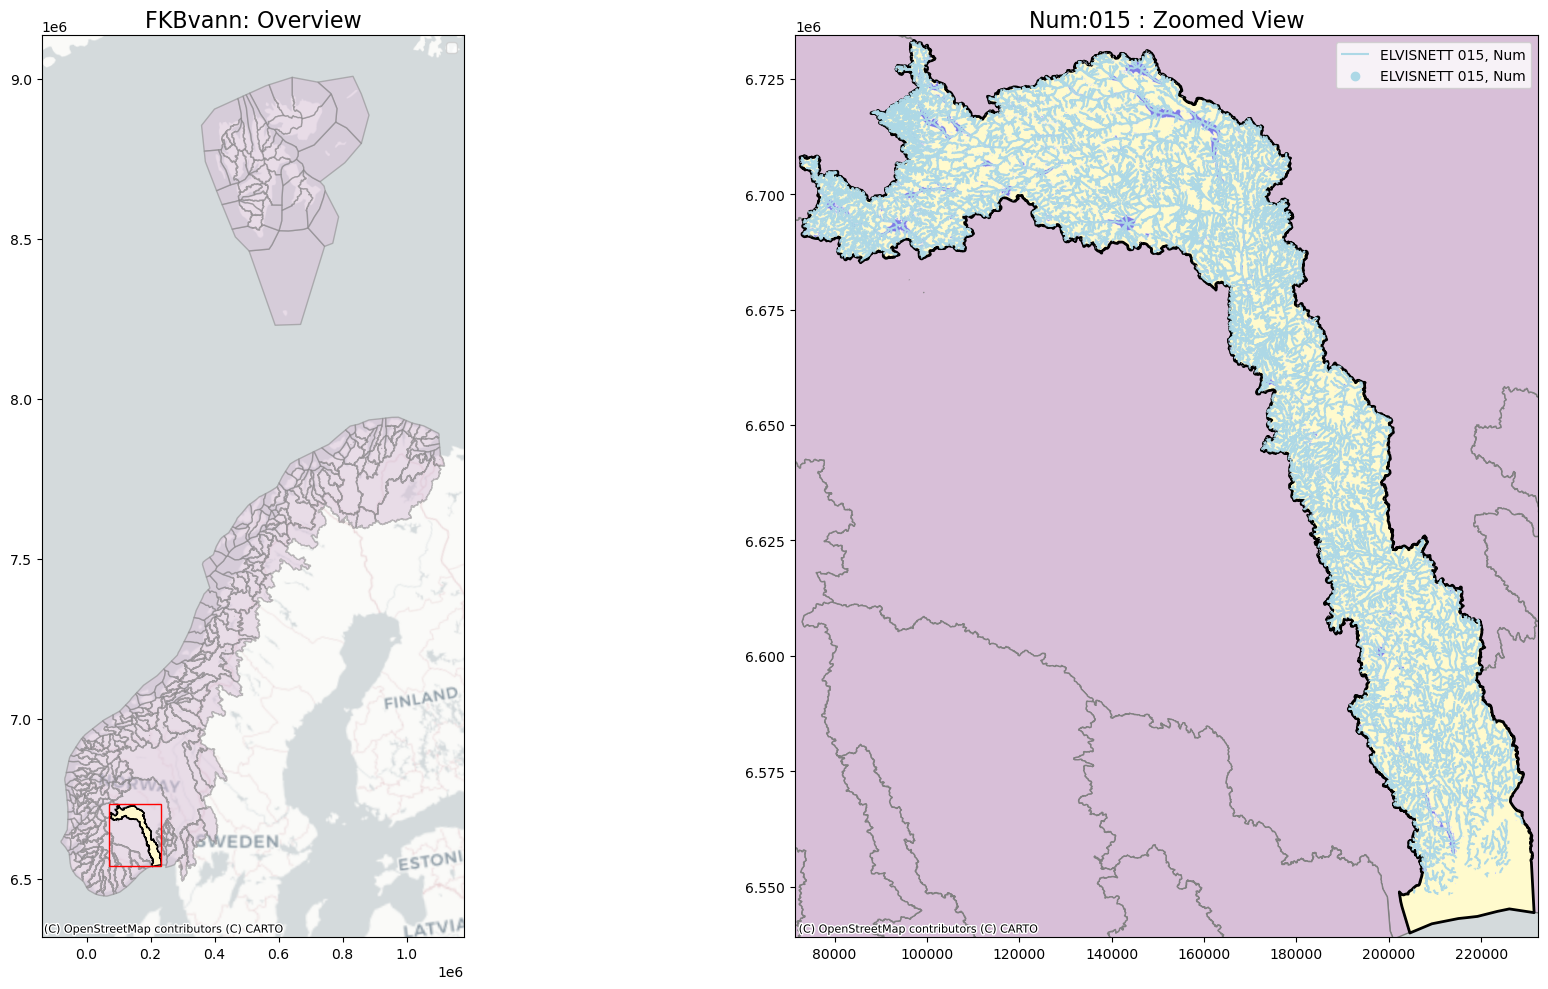

In [56]:
## Plot FKB data on basemap
# This can be removed to save on processing time if needed.
# PREFER TO COMMENT OUT (CTRL+K+C in Visual Studio Code)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# First subplot - Overview
# Plot the water features with different colors and transparency
FKB_Nedborfelt.plot(ax=ax1, color='thistle', edgecolor="grey", linewidth=1, alpha=0.5)
vassdrag_basin_gdf.plot(ax=ax1, color='lemonchiffon', edgecolor='black', linewidth=1)

# Convert the bounding box to Web Mercator for basemap
bbox_webmerc = vassdrag_bbox_gdf.to_crs(epsg=3857)

# Add the basemap using contextily (greyscale)
ctx.add_basemap(ax1, crs=FKB_Nedborfelt.crs.to_string(),
                source=ctx.providers.CartoDB.Positron)

# Add title and legend for first subplot
ax1.set_title('FKBvann: Overview', fontsize=16)
ax1.legend(loc='upper right')

# Second subplot - Zoomed in view
ELVIS_lim_vassdrag.plot(ax=ax2, color='lightblue', label=f'ELVISNETT {vassdrag_nr}, {vassdrag_basin_name}')
FKB_Nedborfelt.plot(ax=ax2, color='thistle', edgecolor="grey", linewidth=1)
vassdrag_basin_gdf.plot(ax=ax2, color='lemonchiffon', edgecolor='black', linewidth=2)
INNSJO_lim_vassdrag.plot(ax=ax2, color='blue', edgecolor='aliceblue', linewidth=0.5, alpha=0.5, label=f'Lakes {vassdrag_nr}, {vassdrag_basin_name}')

# Add the basemap to the zoomed view
ctx.add_basemap(ax2, crs=FKB_Nedborfelt.crs.to_string(),
                source=ctx.providers.CartoDB.Positron)

# Set the extent of the zoomed plot to our area of interest
ax2.set_xlim(dxmin, dxmax)
ax2.set_ylim(dymin, dymax)

# Add title and legend for second subplot
ax2.set_title(f'{vassdrag_basin_name}:{vassdrag_nr} : Zoomed View', fontsize=16)
ax2.legend(loc='upper right')

# Draw a rectangle on the overview plot showing the zoomed area
from matplotlib.patches import Rectangle
rect = Rectangle((dxmin, dymin), dxmax-dxmin, dymax-dymin, 
                 linewidth=1, edgecolor='red', facecolor='none')
ax1.add_patch(rect)

plt.tight_layout()
plt.show()

In [57]:
# # Download and merge 1 m dataset for elevation
# # Use this if need to download a new vassdrag DTM
# # DISABLE OTHERWISE, THIS IS A TIME-CONSUMING STEP
RAW_DTM = f"../RAW/NBF_{vassdrag_basin_name}.tif"

# # Download and automerge
bounds = vassdrag_bounds
bounds = (vassdrag_bounds[0], vassdrag_bounds[1], vassdrag_bounds[2], vassdrag_bounds[3])

if os.path.exists(RAW_DTM):
    print("RS_DTM exists, skipping download.")
else: 
    await hoydedata_api.download_elevation_model(
        bounds=bounds,
        resolution_meters=1, 
        output_path=f"../RAW/NBF_{vassdrag_basin_name}.tif"
    )

# DET KAN SKJE AT VI TRENGER Å INKLUDERE HØYOPPLØSNINGS-SVENSK DATA.

RS_DTM exists, skipping download.


In [58]:
# # If the DTM needs rescaling, use this
RS_DIR = "../OUT/"
RS_DTM = f"{RS_DIR}VD_{vassdrag_basin_name}_R{int(target_res)}m.tif"

if os.path.exists(RS_DTM):
    print(f"RS_DTM already exists at {RS_DTM}, skipping move/resample.")
else:
    if target_res == 1:
        # move and rename RAW data
        print("Target resolution is 1m, moving RAW data without resampling...")
        shutil.move(RAW_DTM, RS_DTM)
        print(f"RAW data moved from RAW to: {RS_DTM}")
    else:
        print("Resampling DTM...")
        resample_tif_by_resolution(RAW_DTM, RS_DTM, target_res)
        print(f"finished and saved to: {RS_DTM}")

RS_DTM already exists at ../OUT/VD_Num_R5m.tif, skipping move/resample.


In [59]:
# Define DTM path for import
# Maintain inclusion of profile, crs and transform for a fixed reference point.

# Read in DTM from RS_DTM
with rasterio.open(RS_DTM) as src:
    # Read in dtm to numpy array
    dtm = src.read(1)
    dtm_profile = src.profile
    dtm_crs = src.crs
    dtm_transform = src.transform

# Clip DTM to exact geom of vassdrag, setting outside values as nodata
# Prep variable dtm_masked for later usage.
shapes = ((geom, 1) for geom in vassdrag_basin_gdf.geometry)
mask = rasterize(
    shapes,
    out_shape=dtm.shape,
    transform=dtm_transform,
    fill=0,
    dtype='uint8'
)

dtm_masked = np.where(mask ==1, dtm, np.nan)

In [60]:
# Robust burn - uses a buffer to ensure river lines are fully captured
# Uses additional components to fully clean up the data
def robust_burn(dtm, transform, river_gdf, burn_depth=5.0, buffer_m=None, all_touched=True,
                close_iter=1, dilate_iter=1):
    px = abs(transform.a)
    if buffer_m is None:
        buffer_m = max(px * 1.0, px * 1.5)  # buffer at least ~1 pixel
    buf = river_gdf.geometry.buffer(buffer_m)
    shapes = ((mapping(g), 1) for g in buf)
    mask = rasterize(shapes, out_shape=dtm.shape, transform=transform, all_touched=all_touched, dtype=np.uint8)
    if close_iter > 0:
        mask = ndimage.binary_closing(mask, iterations=close_iter)
    if dilate_iter > 0:
        mask = ndimage.binary_dilation(mask, iterations=dilate_iter)
    burned = np.minimum(dtm, dtm - burn_depth * mask)
    return burned, mask

In [61]:
## Define variables for burning in of rivers
if ELVIS_lim_vassdrag.crs != dtm_crs:
    rivers_proj = ELVIS_lim_vassdrag.to_crs(dtm_crs)
else:
    rivers_proj = ELVIS_lim_vassdrag

# Optionally mask to basin
if vassdrag_basin_gdf.crs != dtm_crs:
    basin_proj = vassdrag_basin_gdf.to_crs(dtm_crs)
else:
    basin_proj = vassdrag_basin_gdf

# Apply robust burn-in
burned_dtm_rb, river_mask = robust_burn(
    dtm=dtm,
    transform=dtm_transform,
    river_gdf=rivers_proj,
    burn_depth=burn_depth,
    buffer_m=None,   
    all_touched=True,
    close_iter=1,
    dilate_iter=1
)

# Define output location for robust burned DTM
BN_PATH = "../BURNED/"
RBN_DTM = f"{BN_PATH}{versjon}VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

# Export using rasterio, maintaining the original profile but updating the dtype and count for the new data
with rasterio.open(RS_DTM) as src:
    profile = src.profile.copy()
    profile.update(dtype=burned_dtm_rb.dtype, count=1)
    with rasterio.open(RBN_DTM, 'w', **profile, BIGTIFF="YES") as dst:
        dst.write(burned_dtm_rb, 1)
print(f"Robust burned DTM written to: {RBN_DTM}")

Robust burned DTM written to: ../BURNED/v0.9.25VD_Num_RB2_R5m.tif


In [62]:
# Removing vertical noise in the river basin data
# This could be done using filtering, but inverse sinks is more focused.
# Prepare river-and-adjacent-cells inverted DEM for filling
inv_dtm_river = np.full(dtm.shape, -9999, dtype=dtm.dtype)  # nodata everywhere
inv_dtm_river[river_mask.astype(bool)] = -1 * burned_dtm_rb[river_mask.astype(bool)]  # invert at river and adjacent cells (use burned DTM)

# Prep filepaths and save using rasterio
RNET_PATH = '../RNET/'
RNET_FIL = f"{RNET_PATH}{versjon}_VD{vassdrag_basin_name}_INVRIVER_RES{int(target_res)}m.tif"

# Export the river-and-adjacent-cells inverted DEM for filling using rasterio
with rasterio.open(RS_DTM) as src:
    profile = src.profile.copy()
    profile.update(dtype=inv_dtm_river.dtype, count=1, nodata=-9999)
    with rasterio.open(RNET_FIL, 'w', **profile, BIGTIFF="YES") as dst:
        dst.write(inv_dtm_river, 1)
print(f"River-and-adjacent-cells inverted DEM written to: {RNET_FIL}")

# Use pysheds to fill "sinks" as pits and depressions (which are now high spots in original DEM)
rgrid = Grid.from_raster(str(RNET_FIL), data_name='invdem', nodata=-9999)
invdem = rgrid.read_raster(str(RNET_FIL), data_name='invdem', nodata=-9999)
invdem2 = rgrid.fill_pits(invdem)
invdem_filled_neg = rgrid.fill_depressions(invdem2) # Added fill depressions, some areas still problematic.

# Invert back
river_filled = -1 * invdem_filled_neg

# Only update DEM where river mask is True (river and adjacent cells)
burn_dtm_fix = burned_dtm_rb.copy()
burn_dtm_fix[river_mask.astype(bool)] = river_filled[river_mask.astype(bool)]

# Save the result
BN_FIX = f"{BN_PATH}VD_{vassdrag_basin_name}_RB{burn_depth}_FILL_R{int(target_res)}m.tif"
with rasterio.open(RS_DTM) as src:
    profile = src.profile.copy()
    profile.update(dtype=burn_dtm_fix.dtype, count=1)
    with rasterio.open(BN_FIX, 'w', **profile, BIGTIFF="YES") as dst:
        dst.write(burn_dtm_fix, 1)
print(f"Inverse sink-filled river DEM written to: {BN_FIX}")

2026-05-27 13:41:44,089 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support open option DATA_NAME


River-and-adjacent-cells inverted DEM written to: ../RNET/v0.9.25_VDNum_INVRIVER_RES5m.tif


2026-05-27 13:42:38,805 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support open option DATA_NAME


Inverse sink-filled river DEM written to: ../BURNED/VD_Num_RB2_FILL_R5m.tif


In [63]:
# Round the DEM to 2 decimal places before running flow accumulation
# Blockages in the channel in the order of 0.0001 m were causing issues 
# with flow accumulation calculations.
burn_dtm_fix_rounded = np.round(burn_dtm_fix, 2) #Number of decimal places to round to.

# Save the rounded DEM
BN_FIX_RND = f"{BN_PATH}VD_{vassdrag_basin_name}_RB{burn_depth}_FILL_RD_R{int(target_res)}m.tif"
with rasterio.open(RS_DTM) as src:
    profile = src.profile.copy()
    profile.update(dtype=burn_dtm_fix_rounded.dtype, count=1)
    with rasterio.open(BN_FIX_RND, 'w', **profile, BIGTIFF="YES") as dst:
        dst.write(burn_dtm_fix_rounded, 1)
print(f"Rounded inverse sink-filled river DEM written to: {BN_FIX_RND}")

Rounded inverse sink-filled river DEM written to: ../BURNED/VD_Num_RB2_FILL_RD_R5m.tif


In [64]:
FACC_PATH = '../FLOWACC/'
FACC_FIL = f"{FACC_PATH}{versjon}_FAC_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

ELV_PATH = '../ELV/'
ELV_FIL = f"{ELV_PATH}{versjon}_ELV_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.shp"
ELV_FIL_RAS = f"{ELV_PATH}{versjon}_ELV_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

FDIR_PATH = '../FDIR/'
FDIR_FIL = f"{FDIR_PATH}{versjon}_FDIR_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

In [65]:
## Future operations MUST be restricted by area polygon of the vassdrag.
# Clip everything here to basin polygon
with rasterio.open(BN_FIX_RND) as src2:
    # Read in dtm to numpy array
    fixrd_burndtm = src2.read(1)
    fixrd_burndtm_p = src2.profile
    fixrd_burndtm_c = src2.crs
    fixrd_burndtm_t = src2.transform
                    
# Clip burned, fixed, rounded dtm to exact geom of vassdrag, setting outside values as nodata
mask_fixrd_burndtm = np.where(mask ==1, fixrd_burndtm, np.nan)
print("Burned DTM clipped")

Burned DTM clipped


In [66]:
# Pyflwdir flow direction
# Calculate Flow Direction from DTM using pyflwdir
# Prepare DEM for pyflwdir (set nodata to -9999)
dem = mask_fixrd_burndtm.copy()
dem[np.isnan(dem)] = -9999

# Calculate flow direction (D8)
flw = pyflwdir.from_dem(
    data=dem,
    nodata=-9999,
    transform=dtm_transform,
    latlon=dtm_crs.is_geographic,
    outlets="edge", # Edge as test. Min is default.
)

d8_data = flw.to_array(ftype="d8")
print("Flow direction calculated...")

# Pyflwdir flow accumulation
uparea = flw.upstream_area(unit="km2")
print("upstream area calculated...")

# Pyflwdir stream order
streamorder = flw.stream_order(type="strahler")
print("stream order (strahler) calculated...")

Flow direction calculated...
upstream area calculated...
stream order (strahler) calculated...


In [67]:
# Find the minimum stream order where uparea > 0.5 km²
streamorder_masked = np.where(uparea > upa_min, streamorder, 0)
valid_streamorders = streamorder_masked[streamorder_masked > 0]
if valid_streamorders.size > 0:
    min_sto = valid_streamorders.min()
    print(f"Auto-selected min_sto (where uparea > 1.0): {min_sto}")
else:
    min_sto = None
    print("No stream order found where uparea > 1.0.")

# Define output path
STRAHLER_PATH = '../ELV/'
STRAHLER_FIL = f"{STRAHLER_PATH}{versjon}_SORD{min_sto}_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

# # Create stream network raster where stream order >= min_sto
stream_raster = np.where(
    (streamorder_masked >= min_sto) & (uparea >= upa_min),
    1, 0
).astype(np.uint8)
print("Stream raster built")

# Save stream network raster
with rasterio.open(ELV_FIL_RAS, 'w', **dtm_profile) as dst:
    dst.write(stream_raster, 1)

# save streamorder as raster
streamorder_raster = streamorder_masked.astype(np.int32)
with rasterio.open(STRAHLER_FIL, 'w', **dtm_profile, BIGTIFF="YES") as dst:
    dst.write(streamorder_raster, 1)

print("Saved stream network and stream order rasters to:")
print(f"{ELV_FIL_RAS} and {STRAHLER_FIL}")

#Vectorise streams
streams = flw.streams(min_sto=min_sto)

# Convert list of features to GeoDataFrame
streams_gdf = gpd.GeoDataFrame.from_features(streams, crs=dtm_crs)
print("Stream vectors created...")

# Save the streams GeoDataFrame to geojson
streams_gdf.to_file(ELV_FIL)
print(f"Streams GeoDataFrame saved to GPKG: {ELV_FIL}")

Auto-selected min_sto (where uparea > 1.0): 2
Stream raster built
Saved stream network and stream order rasters to:
../ELV/v0.9.25_ELV_VD_Num_RB2_R5m.tif and ../ELV/v0.9.25_SORD2_VD_Num_RB2_R5m.tif
Stream vectors created...


2026-05-27 14:29:48,957 - pyogrio._io - INFO - Created 12,860,100 records


Streams GeoDataFrame saved to GPKG: ../ELV/v0.9.25_ELV_VD_Num_RB2_R5m.shp


In [68]:
streams_gdf.head(2)

,geometry,idx,idx_ds,pit,strord
0,"LINESTRING (73755.769 6708269.167, 73750.768 6...",159497396,159592747,False,2
1,"LINESTRING (73720.768 6708279.167, 73725.768 6...",159433819,159592747,False,2


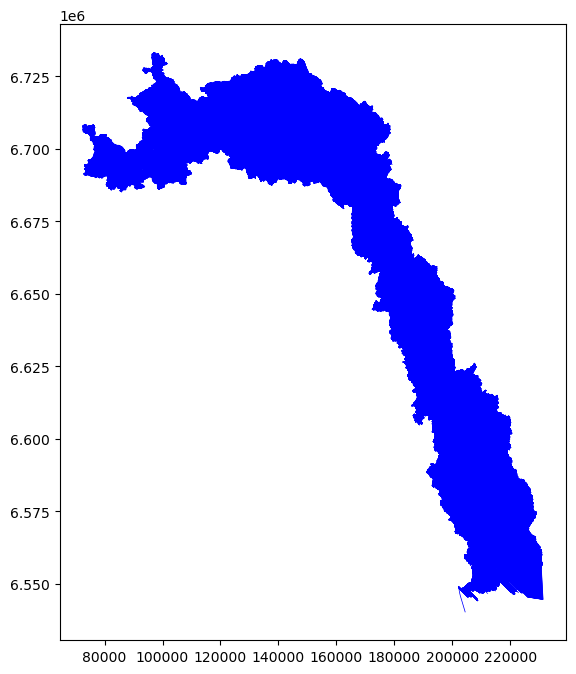

In [69]:
# Plot the streams
fig, ax = plt.subplots(figsize=(10, 8))
#streams_gdf.plot(ax=ax, color='blue', linewidth=0.5)
streams_gdf.plot(ax=ax, color='blue', linewidth=0.5)
plt.show()

In [70]:
# convenience method for vectorizing a raster
def vectorize(data, nodata, transform, crs=dtm_crs, name="value"):
    feats_gen = features.shapes(
        data,
        mask=data != nodata,
        transform=transform,
        connectivity=8,
    )
    feats = [
        {"geometry": geom, "properties": {name: val}} for geom, val in list(feats_gen)
    ]

    # parse to geopandas for plotting / writing to file
    gdf = gpd.GeoDataFrame.from_features(feats, crs=crs)
    gdf[name] = gdf[name].astype(data.dtype)
    return gdf

In [71]:
# Ensure all geodataframes are in the same CRS as the DTM
if INNSJO_lim_vassdrag.crs != dtm_crs:
    innsjo_proj = INNSJO_lim_vassdrag.to_crs(dtm_crs)
else:
    innsjo_proj = INNSJO_lim_vassdrag

if ELVIS_lim_vassdrag.crs != dtm_crs:
    elvis_proj = ELVIS_lim_vassdrag.to_crs(dtm_crs)
else:
    elvis_proj = ELVIS_lim_vassdrag

if streams_gdf.crs != streams_gdf.crs:
    streams_proj = streams_gdf.to_crs(dtm_crs)
else:
    streams_proj = streams_gdf

# 20m buffer around all INNSJO and ELVIS features
innsjo_buffered = innsjo_proj.geometry.buffer(20)
elvis_buffered = elvis_proj.geometry.buffer(20)
streams_buffered = streams_proj.geometry.buffer(20)

# Combine all geometries: original INNSJO polygons + all buffers
elvis_geoms = list(innsjo_proj.geometry) + list(innsjo_buffered) + list(elvis_buffered)
streams_geoms = list(innsjo_proj.geometry) + list(innsjo_buffered) + list(streams_buffered)

# Rasterize: 1 where any geometry exists, 0 elsewhere
elvis_binary = rasterize(
    [(geom, 1) for geom in elvis_geoms],
    out_shape=dtm_masked.shape,
    transform=dtm_transform,
    fill=0,
    dtype='uint8',
    all_touched=True
)

# Rasterize: 1 where any geometry exists, 0 elsewhere
streams_binary = rasterize(
    [(geom, 1) for geom in streams_geoms],
    out_shape=dtm_masked.shape,
    transform=dtm_transform,
    fill=0,
    dtype='uint8',
    all_touched=True
)

In [72]:
def calculate_dVst(stream_facc_km2):
    """
    Calculate dVst for each pixel in stream_facc_km2 according to:
      - dVst = 2 if 0 < value < 1
      - dVst = 0.965 * ln(value) + 2 if 1 <= value <= 500
      - dVst = 8 if value > 500
    Pixels with value <= 0 will be set to np.nan.
    """
    arr = np.asarray(stream_facc_km2)
    dVst = np.full(arr.shape, np.nan, dtype=float)

    mask1 = (arr > 0) & (arr < 1)
    mask2 = (arr >= 1) & (arr <= 500)
    mask3 = arr > 500

    dVst[mask1] = 2
    dVst[mask2] = 0.965 * np.log(arr[mask2]) + 2
    dVst[mask3] = 8

    return dVst

In [73]:
# Generate stream raster arrays for each unique stream order value
unique_stream_orders = np.unique(streamorder_raster)

SR_dict = {}

for so in unique_stream_orders:
    if so >= min_sto:
        sr_name = f"SR_{so:02d}"
        SR_dict[sr_name] = np.where(streamorder_raster == so, 1, 0).astype(np.uint8)
        globals()[sr_name] = SR_dict[sr_name]

# Print the names of all created stream raster variables
print("Created stream raster variables:", list(SR_dict.keys()))

Created stream raster variables: ['SR_02', 'SR_03', 'SR_04', 'SR_05', 'SR_06', 'SR_07', 'SR_08', 'SR_09', 'SR_10', 'SR_11', 'SR_12']


In [74]:
# Create SR_facc_nn arrays for each stream order in SR_dict
SR_facc_dict = {}

for sr_name, sr_data in SR_dict.items():
    # Extract the stream order number (last two digits)
    nn = sr_name.split('_')[-1]
    facc_name = f"SR_facc_{nn}"
    SR_facc_dict[facc_name] = np.where(sr_data == 1, uparea, 0)
    globals()[facc_name] = SR_facc_dict[facc_name]

# Print the names of all created SR_facc_nn arrays
print("Created SR_facc_nn arrays:", list(SR_facc_dict.keys()))

Created SR_facc_nn arrays: ['SR_facc_02', 'SR_facc_03', 'SR_facc_04', 'SR_facc_05', 'SR_facc_06', 'SR_facc_07', 'SR_facc_08', 'SR_facc_09', 'SR_facc_10', 'SR_facc_11', 'SR_facc_12']


In [75]:
# Loop through SR_facc_dict and create elv_vss_nn for each SR_facc_nn
elv_vss_dict = {}

for facc_name, facc_array in SR_facc_dict.items():
    # Extract stream order number (last two digits)
    nn = facc_name.split('_')[-1]
    elv_vss_name = f'elv_vss_{nn}'
    elv_vss_dict[elv_vss_name] = calculate_dVst(facc_array)
    globals()[elv_vss_name] = elv_vss_dict[elv_vss_name]

# Print the names of all created elv_vss_nn arrays
print("Created elv_vss_nn arrays:", list(elv_vss_dict.keys()))

Created elv_vss_nn arrays: ['elv_vss_02', 'elv_vss_03', 'elv_vss_04', 'elv_vss_05', 'elv_vss_06', 'elv_vss_07', 'elv_vss_08', 'elv_vss_09', 'elv_vss_10', 'elv_vss_11', 'elv_vss_12']


In [76]:
# Merge all layers in elv_vss_dict by taking the maximum value at each pixel (ignoring nan)
elv_vss_merged = np.full_like(mask_fixrd_burndtm, np.nan, dtype=float)
for arr in elv_vss_dict.values():
    elv_vss_merged = np.fmax(elv_vss_merged, arr)

# Mask out pixels outside the basin
elv_vss_merged[mask != 1] = np.nan

# Define output file path
ELV_VSS_FIL = f"{ELV_PATH}{versjon}_ELV_VSS_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

# Save the merged raster using the original DTM profile
with rasterio.open(ELV_VSS_FIL, 'w', **profile, BIGTIFF="YES") as dst:
    dst.write(elv_vss_merged, 1)
print(f"Merged elv_vss raster written to: {ELV_VSS_FIL}")

Merged elv_vss raster written to: ../ELV/v0.9.25_ELV_VSS_VD_Num_RB2_R5m.tif


In [77]:
# Iterate through elv_vss_dict and compute cross-section arrays for each stream order
elv_vss_crosssection_dict = {}

for key, elv_vss_layer in elv_vss_dict.items():
    # Find the corresponding stream raster for this stream order
    nn = key.split('_')[-1]
    sr_name = f"SR_{nn}"
    if sr_name in SR_dict:
        sr_raster = SR_dict[sr_name]
        river_mask = (sr_raster == 1) & (~np.isnan(elv_vss_layer))
        distance, (nearest_y, nearest_x) = ndimage.distance_transform_edt(
            ~river_mask, return_indices=True
        )
        elv_vss_crosssection = elv_vss_layer[nearest_y, nearest_x]
        elv_vss_crosssection_dict[f'elv_vss_crosssection_{nn}'] = elv_vss_crosssection

# Print the keys of the resulting dictionary
print("Created elv_vss_crosssection arrays:", list(elv_vss_crosssection_dict.keys()))

Created elv_vss_crosssection arrays: ['elv_vss_crosssection_02', 'elv_vss_crosssection_03', 'elv_vss_crosssection_04', 'elv_vss_crosssection_05', 'elv_vss_crosssection_06', 'elv_vss_crosssection_07', 'elv_vss_crosssection_08', 'elv_vss_crosssection_09', 'elv_vss_crosssection_10', 'elv_vss_crosssection_11', 'elv_vss_crosssection_12']


In [78]:
# Improved assignment: higher stream order rivers overwrite lower ones within threshold ver 25 BEST CASE AS OF LAST UPDATE
streamorder_keys = sorted(elv_vss_crosssection_dict.keys(), key=lambda k: int(k.split('_')[-1]))
streamorder_values = [int(k.split('_')[-1]) for k in streamorder_keys]

# Determine which stream orders are valid for inclusion
min_sto_int = int(min_sto)
max_streamorder = max(streamorder_values)
selected_streamorders = [so for so in streamorder_values if min_sto_int <= so <= max_streamorder]

### Alternate masking - this produces a much less conservative layer, but this also comes with its own issues: New in version 9

In [79]:
# Producing a new raster that connects river pixels to the pixels which drain directly into them.
# Get indices where stream_raster == 1
ys, xs = np.where(streamorder_raster >= min_sto)


# Convert pixel indices to coordinates using the transform
points_geom = [Point(rasterio.transform.xy(dtm_transform, y, x, offset='center')) for y, x in zip(ys, xs)]

# Create GeoDataFrame
points_gdf = gpd.GeoDataFrame(geometry=points_geom, crs=dtm_crs)
x = points_gdf.geometry.x.values
y = points_gdf.geometry.y.values
idxsxy = flw.index(x, y)

# Produce basins for each river point.
bas = flw.basins(idxsxy)
print("Basins calculated for all river pixels...")

Basins calculated for all river pixels...


In [80]:
# Vectorising and appending stream order values.
print("Vectorizing basins raster...")
basins_gdf = vectorize(
    data=bas.astype(np.int32),
    nodata=0,
    transform=dtm_transform,
    crs=dtm_crs,
    name="basin_id"
)
print(f"  Done. {len(basins_gdf)} polygons created.")

print("Calculating max stream order for each basin (fast method)...")
labels = bas.astype(np.int32)
strorders = streamorder_raster.astype(np.int32)
basin_ids = np.unique(labels)
basin_ids = basin_ids[basin_ids != 0]  # skip background

# Use ndimage.labeled_comprehension for fast max calculation
max_strorders = ndimage.labeled_comprehension(
    strorders, labels, basin_ids, np.nanmax, float, 0
)
basin_id_to_max_so = dict(zip(basin_ids, max_strorders.astype(int)))

basins_gdf["streamorder"] = basins_gdf["basin_id"].map(basin_id_to_max_so).fillna(0).astype(int)
print("  Done. Stream order assigned to polygons.")

Vectorizing basins raster...
  Done. 872515 polygons created.
Calculating max stream order for each basin (fast method)...
  Done. Stream order assigned to polygons.


In [81]:
print("Rasterizing basins_gdf using streamorder...")

# Prepare shapes: (geometry, value) tuples
shapes = zip(basins_gdf.geometry, basins_gdf["streamorder"])

# Use the same shape and transform as dtm_masked
out_shape = dtm_masked.shape
transform = dtm_transform

# Rasterize: pixels get streamorder value, 0 elsewhere
basins_streamorder_raster = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    fill=0,
    dtype="int32"
)
print("  Done. Basins rasterized with stream order values.")

Rasterizing basins_gdf using streamorder...
  Done. Basins rasterized with stream order values.


In [82]:
# Identify all stream orders in elv_vss_crosssection_dict containing a pixel with value 8
streamorders_with_8 = []
for key, arr in elv_vss_crosssection_dict.items():
    if np.any(arr == 8):
        so = int(key.split('_')[-1])
        streamorders_with_8.append(so)

print(f"Stream orders containing a pixel with value 8: {streamorders_with_8}")

# Buffering basins_streamorder_raster for stream orders with value 8
pixel_size = abs(dtm_transform.a)  # assumes square pixels
buffer_pixels = int(np.ceil(buffer_distance_m / pixel_size))

# Create a mask for all stream orders with value 8
buffer_mask = np.isin(basins_streamorder_raster, streamorders_with_8)

# Apply a 100m buffer using binary dilation
buffered_mask = ndimage.binary_dilation(buffer_mask, iterations=buffer_pixels)

# Replace values within 100m of stream orders with value 8 with their streamorder value
# Only update where buffered_mask is True and basins_streamorder_raster is not already one of the streamorders_with_8
for so in streamorders_with_8:
    so_mask = (basins_streamorder_raster == so)
    so_buffered = ndimage.binary_dilation(so_mask, iterations=buffer_pixels)
    # Assign streamorder value to buffered area, but only where not already that value
    basins_streamorder_raster[(so_buffered) & (basins_streamorder_raster != so)] = so

print(f"Applied {buffer_distance_m} buffer to basins_streamorder_raster for stream orders with value 8.")

Stream orders containing a pixel with value 8: [11, 12]
Applied 25 buffer to basins_streamorder_raster for stream orders with value 8.


##### NEW HAND LOCATION v 0.9.04

In [83]:
# # HAND Contour method
print("Calculating HAND using contour method...")
drainage_mask = streamorder_raster >= min_sto
HAND = flw.hand(drainage_mask, dtm_masked)
print("  Done. HAND calculated.")

Calculating HAND using contour method...
  Done. HAND calculated.


In [84]:
# Define flood path:
# Define output
FLD_PATH = '../FLD/'

print("Interpolating negative HAND values and applying Gaussian filter...")
# Identify negative values (excluding river pixels)
neg_mask = (HAND < 0) & (HAND != 0)

# Prepare a mask of valid (non-negative or river) values
valid_mask = ~neg_mask

# Interpolate negative values using nearest neighbor from valid pixels
inds = ndimage.distance_transform_edt(valid_mask == 0, return_distances=False, return_indices=True)
hand_interpolated = HAND[tuple(inds)]
HAND[neg_mask] = hand_interpolated[neg_mask]

# Apply a light Gaussian filter to the HAND raster
# sigma=1 is gentle, increase for more smoothing
HAND_smoothed = ndimage.gaussian_filter(HAND, sigma=1)

# Only update negative (non-river) pixels with the smoothed values
HAND[neg_mask] = HAND_smoothed[neg_mask]

with rasterio.open(f"{FLD_PATH}{versjon}_HAND_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif", 'w', **dtm_profile) as dst:
    dst.write(HAND, 1)
print("  Done. HAND raster saved.")

Interpolating negative HAND values and applying Gaussian filter...
  Done. HAND raster saved.


In [85]:
#elv_vss_crosssection_weighted = np.full_like(nearest_weighted, np.nan, dtype=float)
elv_vss_crosssection_weighted = np.full_like(basins_streamorder_raster, np.nan, dtype=float)

for so in selected_streamorders:
    layer_key = f'elv_vss_crosssection_{so:02d}'
    layer = elv_vss_crosssection_dict[layer_key]
    #maskv = nearest_weighted == so
    maskv = basins_streamorder_raster == so
    # Assign the value from the crosssection layer for pixels with this stream order
    elv_vss_crosssection_weighted[maskv] = layer[maskv]

In [86]:
print("Calculating aktsomhetsområde area, depth and vannstandstigning...")
aktsomhetsområde_layer = np.where(elv_vss_crosssection_weighted > HAND,
                                   1, 0).astype(np.uint8)
aktsomhetsområde_dybde = np.where(elv_vss_crosssection_weighted > HAND, 
                                  elv_vss_crosssection_weighted - HAND, 0)
aktsomhetsområde_vss = np.where(elv_vss_crosssection_weighted > HAND,
                                elv_vss_crosssection_weighted, 0)

# Define save locations and save
AKT_FIL_DYP = f"{FLD_PATH}{versjon}_AKT_DYBDE_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"
AKT_FIL_VSS = f"{FLD_PATH}{versjon}_AKT_VSS_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"

#Build Mask
aktsomhetsområde_nanmask = np.where(aktsomhetsområde_layer == 1, 1, np.nan)

aktdepth = np.where(mask == 1, aktsomhetsområde_dybde, np.nan)
aktvss = np.where(mask == 1, aktsomhetsområde_vss, np.nan)
                    
# Save the aktsomhetsområde raster to file with nodata=-9999 for ArcGIS Pro compatibility
akt_profile = dtm_profile.copy()
akt_profile.update(nodata=-9999)

# Save using the mask: only write values where mask is 1, else np.nan
with rasterio.open(AKT_FIL_DYP, 'w', **akt_profile) as dst:
    dst.write(np.where(aktsomhetsområde_nanmask == 1, aktdepth, np.nan), 1)

with rasterio.open(AKT_FIL_VSS, 'w', **akt_profile) as dst:
    dst.write(np.where(aktsomhetsområde_nanmask == 1, aktvss, np.nan), 1)

print(f"  Done. Aktsomhetsområde rasters saved to {AKT_FIL_DYP} and {AKT_FIL_VSS}.")

Calculating aktsomhetsområde area, depth and vannstandstigning...
  Done. Aktsomhetsområde rasters saved to ../FLD/v0.9.25_AKT_DYBDE_VD_Num_RB2_R5m.tif and ../FLD/v0.9.25_AKT_VSS_VD_Num_RB2_R5m.tif.


In [87]:
# Create an uncertainty layer based on +/- 10% of the cross-section values
elv_vss_crosssection_weighted_plus10percent = elv_vss_crosssection_weighted * 1.10
elv_vss_crosssection_weighted_minus10percent = elv_vss_crosssection_weighted * 0.90

# Create aktsomhetsområde-like layers for plus and minus 10% scenarios
aktsomhetsområde_layer_plus10percent = np.where(elv_vss_crosssection_weighted_plus10percent > HAND, 1, 0).astype(np.uint8)
aktsomhetsområde_layer_minus10percent = np.where(elv_vss_crosssection_weighted_minus10percent > HAND, 1, 0).astype(np.uint8)

# Create a layer where 1 = aktsomhetsområde plus 10%, 2 = aktsomhetsområde, 3 = aktsomhetsområde minus 10%
aktsomhetsområde_uncertainty = np.zeros_like(aktsomhetsområde_layer, dtype=np.uint8)
aktsomhetsområde_uncertainty[aktsomhetsområde_layer_plus10percent == 1] = 1
aktsomhetsområde_uncertainty[aktsomhetsområde_layer == 1] = 2
aktsomhetsområde_uncertainty[aktsomhetsområde_layer_minus10percent == 1] = 3

# Write out at AKT_UNCERT
AKT_UNCERT_FIL = f"{FLD_PATH}{versjon}_AKT_UNCERT_VD_{vassdrag_basin_name}_RB{burn_depth}_R{int(target_res)}m.tif"
with rasterio.open(AKT_UNCERT_FIL, 'w', **akt_profile) as dst:
    dst.write(aktsomhetsområde_uncertainty, 1)

In [88]:
# legal requirements to aktsomhetsområde including elv & innsjø buffer
# Add streams binary to aktsomhetsområde so where streams_binary or aktsomhetsområde is 1, output is 1
print("Adding legal requirement of 20 m buffer...")
aktsomhetsområde_lov_DTM = np.where((aktsomhetsområde_layer == 1) | (streams_binary == 1), 1, 0).astype(np.uint8)
aktsomhetsområde_lov_ELVIS = np.where((aktsomhetsområde_layer == 1) | (elvis_binary == 1), 1, 0).astype(np.uint8)
# aktsomhetsområde_lov_DTM = np.where(mask ==1, aktsomhetsområde_lov_DTM, 0)
aktsomhetsområde_lov_ELVIS = np.where(mask ==1, aktsomhetsområde_lov_ELVIS, 0) 
aktsomhetsområde_total = np.where(aktsomhetsområde_lov_DTM == 1, 1, 0) | np.where(aktsomhetsområde_lov_ELVIS == 1, 1, 0)

Adding legal requirement of 20 m buffer...


In [89]:
# Test version using aktomr_lov_DTM but without mask.
with rasterio.open("../test/test_akt_lov_DTM.tif", 'w', **akt_profile) as dst:
    dst.write(aktsomhetsområde_lov_DTM, 1)

In [90]:
# Produce rasters
# AKT_FIL_TOT = f"{FLD_PATH}{versjon}_AKT_TOT_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.tif"
# with rasterio.open(AKT_FIL_TOT, 'w', **akt_profile, BIGTIFF="YES") as dst:
#     arr = np.where(aktsomhetsområde_total == 0, -9999, aktsomhetsområde_total)
#     dst.write(arr, 1)

# From version 0.9.25 we no longer produce "total" due to issues. We use ELVIS only.
AKT_FIL_TOT = f"{FLD_PATH}{versjon}_AKT_TOT_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.tif"
with rasterio.open(AKT_FIL_TOT, 'w', **akt_profile, BIGTIFF="YES") as dst:
    arr = np.where(aktsomhetsområde_lov_ELVIS == 0, -9999, aktsomhetsområde_total)
    dst.write(arr, 1)

In [91]:
# Produce polygons
# Vectorise the data
AKT_TOT_VEC = vectorize(
    data=aktsomhetsområde_lov_ELVIS.astype(np.int32),
    nodata=0,
    transform=flw.transform,
    crs=dtm_crs,
    name=f"{vassdrag_nr}_BUFFERID"
)
# Print out total file
AKT_FIL_TOT_VEC= f"{FLD_PATH}{versjon}_AKT_TOT_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.gpkg"
AKT_TOT_VEC.to_file(AKT_FIL_TOT_VEC, driver="GPKG")

print(f"  Done. Total Aktsomhetsområde raster saved to {AKT_FIL_TOT}, vector saved to {AKT_FIL_TOT_VEC}.")

2026-05-27 17:23:52,551 - pyogrio._io - INFO - Created 4,148 records


  Done. Total Aktsomhetsområde raster saved to ../FLD/v0.9.25_AKT_TOT_VD_Num_STO2_RB2_R5m.tif, vector saved to ../FLD/v0.9.25_AKT_TOT_VD_Num_STO2_RB2_R5m.gpkg.


# SPLITHAND TESTS

#### Major issues in splithand with areas that are NOT Gaula.

This code section is defunct from version 0.9.25 until further notice.
- Appears to require editing in some way so that depth values are clipped to the stream network
- In this case the stream network needs to be the NVE mapped one, as the stream network generated by the DTM is bad.
- May need alternative methodology for calculating HAND using ELVIS.

In [92]:
# # Calculate HAND for each stream order value.
# hand_results = {}

# # Calculate HAND for each unique strord value (no buffer)
# if "strord" in streams_gdf.columns:
#     unique_strords = sorted(streams_gdf["strord"].unique())
# else:
#     raise ValueError("streams_gdf must have a 'strord' column.")

# print(f"Starting HAND calculation for each strord value: {unique_strords}")

# for strord_val in unique_strords:
#     print(f"\nProcessing strord value: {strord_val}")

#     # Select all streams with this strord
#     streams_sel = streams_gdf[streams_gdf["strord"] == strord_val]
#     print(f"  Number of stream segments: {len(streams_sel)}")

#     # Combine all geometries for this strord into a single MultiLineString
#     combined_geom = streams_sel.unary_union

#     # Rasterize all streams of this strord to create the drain mask (no buffer)
#     drain_mask = rasterize(
#         [(combined_geom, 1)],
#         out_shape=dtm_masked.shape,
#         transform=dtm_transform,
#         fill=0,
#         dtype='uint8',
#         all_touched=True
#     ).astype(bool)

#     if not np.any(drain_mask):
#         print(f"  Skipping strord {strord_val}: no stream in raster extent.")
#         continue
#     print(f"  Drain mask rasterized.")

#     # Use the full dtm_masked as the elevation input (no buffer)
#     elevtn = dtm_masked
#     print(f"  Using full DEM for HAND calculation.")

#     # Calculate HAND for this strord
#     print(f"  Calculating HAND for strord {strord_val} ...")
#     hand_arr = flw.hand(drain=drain_mask, elevtn=elevtn)
#     hand_results[strord_val] = hand_arr
#     print(f"  HAND calculation complete for strord {strord_val}.")

# print("\nAll HAND calculations for each strord value complete.")
# # ...existing code...

In [93]:
# # Calculate inundation rasters for each stream order using elv_vss_crosssection_dict and hand_results
# aktsomhet_strord_dict = {}

# print("Calculating inundation rasters (aktsomhet_strord) for each stream order...")

# for key, elv_vss_crosssection in elv_vss_crosssection_dict.items():
#     # Extract stream order number (last two digits)
#     nn = key.split('_')[-1]
#     strord_val = int(nn)
#     if strord_val in hand_results:
#         hand_arr = hand_results[strord_val]
#         # Compare elv_vss_crosssection to HAND: 1 if water rise > HAND, else 0
#         aktsomhet_strord = np.where(elv_vss_crosssection > hand_arr, 1, 0).astype(np.uint8)
#         aktsomhet_strord_dict[f"aktsomhet_strord_{nn}"] = aktsomhet_strord
#         print(f"  Created aktsomhet_strord_{nn} for stream order {strord_val}")
#     else:
#         print(f"  No HAND result for stream order {strord_val}, skipping.")

# print("All aktsomhet_strord layers created.")

# # Calculate depth for each aktsomhet_strord layer: (elv_vss_crosssection - HAND) where aktsomhet_strord == 1, else 0
# aktsomhet_strord_depth_dict = {}

# for key, mask_arr in aktsomhet_strord_dict.items():
#     nn = key.split('_')[-1]
#     strord_val = int(nn)
#     # Get the corresponding VSS crosssection and HAND arrays
#     vss_arr = elv_vss_crosssection_dict[f'elv_vss_crosssection_{nn}']
#     hand_arr = hand_results.get(strord_val)
#     if hand_arr is not None:
#         depth_arr = np.where(mask_arr == 1, vss_arr - hand_arr, 0)
#         aktsomhet_strord_depth_dict[f"aktsomhet_strord_depth_{nn}"] = depth_arr
#         print(f"Calculated depth for aktsomhet_strord_{nn}")
#     else:
#         print(f"No HAND for stream order {strord_val}, skipping depth.")

In [94]:
# # Define output filenames
# SPLITHAND_EXTENT = f"{FLD_PATH}{versjon}_SPLITHAND_EXT_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.tif"
# SPLITHAND_DEPTH_UNINTERP = f"{FLD_PATH}{versjon}_SPLITHAND_DEPTH_UNINTERP_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.tif"
# SPLITHAND_DEPTH_INTERP = f"{FLD_PATH}{versjon}_SPLITHAND_DEPTH_INTERP_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.tif"
# SPLITHAND_EXTENT_VEC = f"{FLD_PATH}{versjon}_SPLITHAND_EXT_VD_{vassdrag_basin_name}_STO{min_sto}_RB{burn_depth}_R{int(target_res)}m.gpkg"

In [95]:
# # Merge depth layers, preferring values from the highest stream order first,
# # but if the value is zero, take the value from the next lower stream order, and so on.
# # After merging, set any values > 8 to 0.

# # Sort keys by stream order descending (highest first)
# sorted_keys = sorted(
#     aktsomhet_strord_depth_dict.keys(),
#     key=lambda k: int(k.split('_')[-1]),
#     reverse=True
# )

# # Start with all values as np.nan (so we can distinguish unset pixels)
# depth_pref = np.full_like(next(iter(aktsomhet_strord_depth_dict.values())), np.nan, dtype=np.float32)

# for key in sorted_keys:
#     arr = aktsomhet_strord_depth_dict[key]
#     # Fill where depth_pref is nan and arr > 0
#     mask = np.isnan(depth_pref) & (arr > 0)
#     depth_pref[mask] = arr[mask]

# # After all layers, set remaining np.nan to 0 (no valid depth found in any layer)
# depth_pref[np.isnan(depth_pref)] = 0

# # Set any values > 8 to 0
# depth_pref_binarising = depth_pref.copy()

# depth_pref_binarising[depth_pref_binarising > 8] = 0

# # --- Burn in buffered lakes and streams as value 1 ---
# depth_pref_binarising[(streams_binary == 1) | (elvis_binary == 1)] = 1

# # After all layers, set remaining np.nan to 0 (no valid depth found in any layer)
# depth_pref_binarising[np.isnan(depth_pref_binarising)] = 0

# # --- Binarise: 1 where 0 < depth_pref <= 8, else 0 ---
# depth_pref_bin = np.where((depth_pref_binarising > 0) & (depth_pref_binarising <= 8), 1, 0).astype(np.uint8)

# profile = dtm_profile.copy()
# profile.update(dtype=np.float32, count=1, nodata=0)

# # Interpolation
# depth_pref_interp = depth_pref.copy()

# # After all layers, set remaining np.nan to 0 (no valid depth found in any layer)
# depth_pref_interp[np.isnan(depth_pref_interp)] = 0

# # Mask for values to interpolate (depth > 8)
# over8_mask = (depth_pref_interp > 8) & (depth_pref_bin == 1)

# # Mask for valid values (depth <= 8 and > 0) within the extent
# valid_mask = (depth_pref_interp <= 8) & (depth_pref_interp > 0) & (depth_pref_bin == 1)

# if np.any(over8_mask) and np.any(valid_mask):
#     # Use nearest neighbor interpolation from valid values, but only within the extent
#     inds = ndimage.distance_transform_edt(~valid_mask, return_distances=False, return_indices=True)
#     interpolated = depth_pref_interp[tuple(inds)]
#     # Only update where depth_pref > 8 and within the extent
#     depth_pref_interp[over8_mask] = interpolated[over8_mask]
#     # If any values are still > 8 (e.g., surrounded by other >8), clip to 8
#     depth_pref_interp[(depth_pref_interp > 8) & (depth_pref_bin == 1)] = 8

# # Finish by replacing any value above 8 in depth_pref_interp with 0
# depth_pref_interp[(depth_pref_interp > 8)] = 0


# # with rasterio.open(SPLITHAND_DEPTH_INTERP, 'w', **profile) as dst:
# #     dst.write(depth_pref_interp, 1)

# print(f"Depth preference raster (highest stream order wins, fallback to lower orders if <=0, interpolated where >8, only within extent)")


In [96]:
# # Fix extents, so all values outside of dtm_masked area (the basin) are set to nodata.
# # First uninterpolated
# depth_pref_clipped = depth_pref.copy()
# depth_pref_clipped[np.isnan(dtm_masked)] = -9999
# depth_pref_clipped[depth_pref ==0] = -9999
# depth_pref_clipped[depth_pref ==10007] = -9999

# depth_pref_bin_clipped = depth_pref_bin.copy()
# depth_pref_bin_clipped[np.isnan(dtm_masked)] = -9999
# depth_pref_bin_clipped[depth_pref_bin ==0] = -9999

# depth_pref_interp_clipped = depth_pref_interp.copy()
# depth_pref_interp_clipped[np.isnan(dtm_masked)] = -9999
# depth_pref_interp_clipped[depth_pref_interp ==0] = -9999

# profile_clip = dtm_profile.copy()
# profile_clip.update(dtype='float32', count=1, nodata=-9999)


# # Set all values where dtm_masked is nan to -9999 (or np.nan if you prefer)
# depth_pref_clipped = depth_pref.copy()
# depth_pref_clipped[np.isnan(dtm_masked)] = -9999  # or np.nan if you want nan

# with rasterio.open(SPLITHAND_EXTENT, 'w', **profile_clip) as dst:
#     dst.write(depth_pref_bin, 1)
# with rasterio.open(SPLITHAND_DEPTH_UNINTERP, 'w', **profile_clip) as dst:
#     dst.write(depth_pref, 1)
# with rasterio.open(SPLITHAND_DEPTH_INTERP, 'w', **profile_clip) as dst:
#     dst.write(depth_pref_interp, 1)

# ## SPLITHAND VECTORISERING
# # Produce polygons
# # Vectorise the data
# SPLIT_VEC = vectorize(
#     data=depth_pref_bin.astype(np.int32),
#     nodata=0,
#     transform=flw.transform,
#     crs=dtm_crs,
#     name=f"{vassdrag_nr}_BUFFERID"
# )
# # Print out total file
# SPLIT_VEC.to_file(AKT_FIL_TOT_VEC, driver="GPKG")